# Each app and the associated stereotype

We wanted to find out if the stereotypes are true. We grouped questions that have influence on particular stereotypes that are being told about 
particular apps.


In [2]:
# load libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter
import numpy as np
from scipy.stats import gaussian_kde
import json, re

# data
data = pd.read_csv('../data/smmh.csv')

Renaming the columns and getting the mean values for each question

In [3]:
# -----------------------------
# COLUMN DEFINITIONS
# -----------------------------
question_cols = {
    9: "9. How often do you find yourself using Social media without a specific purpose?",
    10: "10. How often do you get distracted by Social media when you are busy doing something?",
    11: "11. Do you feel restless if you haven't used Social media in a while?",
    12: "12. On a scale of 1 to 5, how easily distracted are you?",
    13: "13. On a scale of 1 to 5, how much are you bothered by worries?",
    14: "14. Do you find it difficult to concentrate on things?",
    15: "15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?",
    16: "16. Following the previous question, how do you feel about these comparisons, generally speaking?",
    17: "17. How often do you look to seek validation from features of social media?",
    18: "18. How often do you feel depressed or down?",
    19: "19. On a scale of 1 to 5, how frequently does your interest in daily activities fluctuate?",
    20: "20. On a scale of 1 to 5, how often do you face issues regarding sleep?"
}

platform_col = "7. What social media platforms do you commonly use?"

# -----------------------------
# CREATE PLATFORM TABLE
# -----------------------------
platforms = [
    "Instagram",
    "Facebook",
    "Twitter",
    "YouTube",
    "Discord",
    "Pinterest",
    "TikTok",
    "Snapchat",
    "Reddit",
    "LinkedIn"
]

results = []

for platform in platforms:

    subset = data[
        data[platform_col]
        .fillna("")
        .str.contains(platform, case=False)
    ]

    if len(subset) == 0:
        continue

    row = {
        "Platform": platform,
        "Users": len(subset),
        "Average Age": subset["1. What is your age?"].mean(),
    }

    # Mean scores for Q9-Q20
    for q_num, q_col in question_cols.items():
        row[f"Q{q_num}"] = pd.to_numeric(
            subset[q_col],
            errors="coerce"
        ).mean()

    results.append(row)

platform_scores = pd.DataFrame(results)

# -----------------------------
# PRINT SUMMARY
# -----------------------------
print(platform_scores.round(2))

    Platform  Users  Average Age    Q9   Q10   Q11   Q12   Q13   Q14   Q15  \
0  Instagram    359        24.37  3.64  3.48  2.67  3.48  3.75  3.39  2.93   
1   Facebook    407        26.15  3.58  3.40  2.64  3.36  3.61  3.28  2.92   
2    Twitter    131        26.89  3.54  3.18  2.55  3.34  3.68  3.16  2.66   
3    YouTube    412        25.87  3.59  3.34  2.59  3.35  3.60  3.24  2.85   
4    Discord    198        22.81  3.67  3.43  2.55  3.48  3.75  3.40  2.79   
5  Pinterest    145        24.57  3.62  3.36  2.57  3.35  3.72  3.17  2.85   
6     TikTok     94        23.67  3.84  3.78  3.02  3.80  4.03  3.66  3.40   
7   Snapchat    181        22.76  3.72  3.60  2.78  3.61  3.84  3.51  3.04   
8     Reddit    126        23.56  3.68  3.20  2.38  3.43  3.73  3.30  2.60   

    Q16   Q17   Q18   Q19   Q20  
0  2.75  2.54  3.40  3.28  3.30  
1  2.74  2.53  3.31  3.17  3.25  
2  2.75  2.31  3.25  2.97  3.21  
3  2.78  2.46  3.28  3.18  3.22  
4  2.85  2.38  3.41  3.18  3.40  
5  2.79  2.50  

Heatmap allow us to see the scores for each question and each platform. We can easily read which questions are the most concerning - have the highest scores across all types of social media (Q9 How often do you find yourself using Social media without a specific purpose? and Q13 On a scale of 1 to 5, how much are you bothered by worries?) and which platform has generally elevated scores - TikTok. 
For the website we chose to represent this data in a word map where the bigger is the name of the platform the higher it scored in the question. 

In [ ]:
# -----------------------------
# HEATMAP VISUALIZATION
# -----------------------------
score_cols = [f"Q{i}" for i in range(9, 21)]

heatmap_data = platform_scores.set_index("Platform")[score_cols]

fig, ax = plt.subplots(figsize=(14, 6))

im = ax.imshow(heatmap_data, aspect='auto')

# Axis labels
ax.set_xticks(np.arange(len(score_cols)))
ax.set_yticks(np.arange(len(heatmap_data.index)))

ax.set_xticklabels(score_cols)
ax.set_yticklabels(heatmap_data.index)

plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Add values inside cells
for i in range(len(heatmap_data.index)):
    for j in range(len(score_cols)):
        value = heatmap_data.iloc[i, j]
        ax.text(j, i, f"{value:.1f}",
                ha="center",
                va="center")

ax.set_title("Average scores by platform (Q9-Q20)")

fig.colorbar(im)

plt.tight_layout()
plt.show()



NameError: name 'platform_scores' is not defined

After seeing the heatmap, we suspect that TikTok, despite the low ammount of users in this cohort, is associated with many negative effects on mental health. 
For the website we chose to represent this data in a word map where the bigger is the name of the platform the higher it scored in the question. For further analysis we exclude this app to see more telling data.

   Question Most Associated Platform(s)  Average Score
0        Q9                           i           3.60
1       Q10                        k, k           3.39
2       Q11                        k, k           2.65
3       Q12                           i           3.43
4       Q13                           i           3.67
5       Q14                           i           3.32
6       Q15                        k, k           2.93
7       Q16                           o           2.77
8       Q17                        k, k           2.53
9       Q18                           i           3.35
10      Q19                           i           3.23
11      Q20                        k, k           3.26


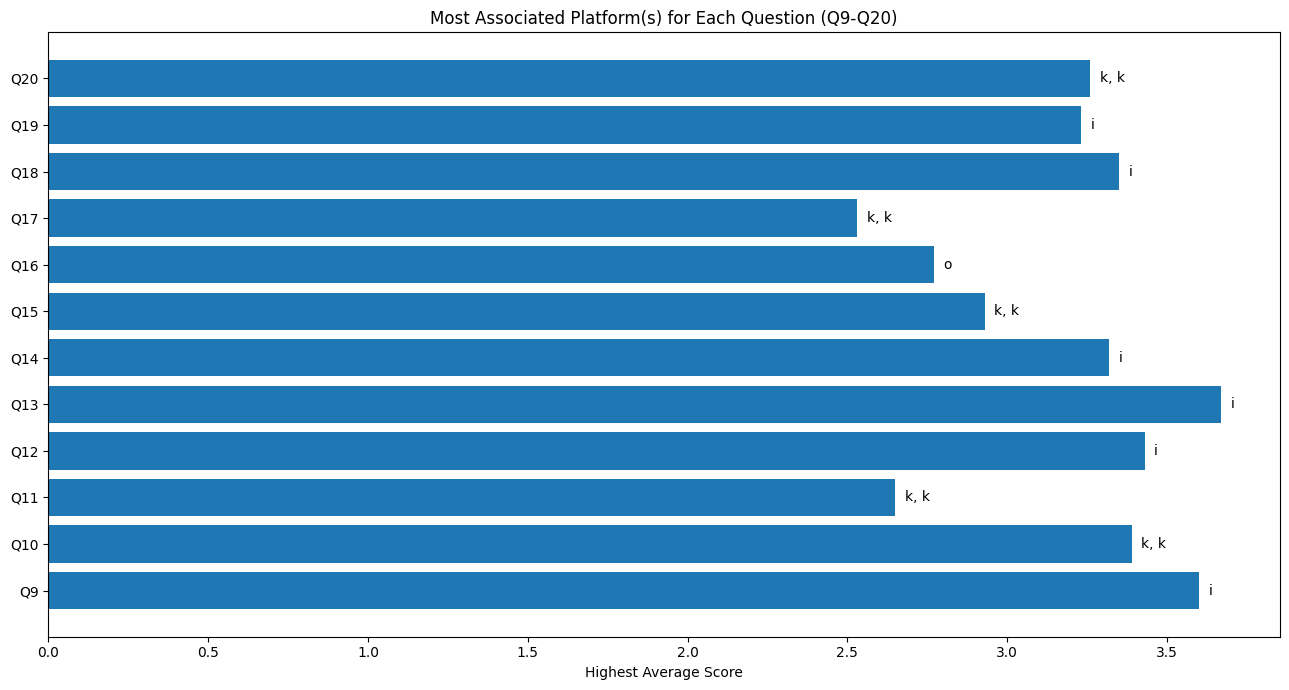

In [8]:
# -----------------------------
# CALCULATE PLATFORM MEANS
# -----------------------------
results = []

for platform in platforms:

    subset = data[
        data[platform_col]
        .fillna("")
        .str.contains(platform, case=False)
    ]

    if len(subset) == 0:
        continue

    row = {"Platform": platform}

    for q_num, q_col in question_cols.items():

        row[f"Q{q_num}"] = pd.to_numeric(
            subset[q_col],
            errors="coerce"
        ).mean()

    results.append(row)

scores_data = pd.DataFrame(results)

# -----------------------------
# FIND MOST ASSOCIATED PLATFORM(S)
# includes ties
# -----------------------------
summary_rows = []

for q_num in range(9, 21):

    q_col = f"Q{q_num}"

    max_score = scores_data[q_col].max()

    best_platforms = scores_data.loc[
        scores_data[q_col] == max_score,
        "Platform"
    ].tolist()

    summary_rows.append({
        "Question": q_col,
        "Most Associated Platform(s)": ", ".join(best_platforms),
        "Average Score": round(max_score, 2)
    })

summary_data = pd.DataFrame(summary_rows)

print(summary_data)

# -----------------------------
# VISUALIZATION WITH TIES
# -----------------------------
fig, ax = plt.subplots(figsize=(13, 7))

bars = ax.barh(
    summary_data["Question"],
    summary_data["Average Score"]
)

for i, bar in enumerate(bars):

    platforms = summary_data.iloc[i]["Most Associated Platform(s)"]

    ax.text(
        bar.get_width() + 0.03,
        bar.get_y() + bar.get_height() / 2,
        platforms,
        va="center"
    )

ax.set_xlabel("Highest Average Score")
ax.set_title("Most Associated Platform(s) for Each Question (Q9-Q20)")

plt.tight_layout()
plt.show()